DI725 Term Project - Proof of Concept

Research Question: Does adding textual information improve remote sensing image classification performance compared to image only inputs?

Google Drive Link:https://drive.google.com/drive/folders/1f-3Tu53bY1zJ2Xg2qfjUn6oSSuXeHmv8?usp=drive_link

The goal of this project is to investigate whether textual information improves classification performance compared to image only inputs.

Ground truth labels are derived from segmentation masks. Pixel wise class distribution is used for that purpose.

A FLAVA model is used to process both image only and image+text inputs, since FLAVA is a unified multimodal transformer that can handle image, text, and combined image text data.

This proof of concept (PoC) focuses on validating the feasibility of the pipeline. Accuracy and other performance metrics are not the primary focus at this stage.

**1-Importing Required Libraries and Data Loading**

In this step, images, segmentation masks, and caption data are loaded from the dataset.

*   Images: RGB remote sensing images
*   Masks: Pixel wise segmentation maps
*   Captions: Textual descriptions generated by different models

Using GitHub was not feasible due to the very large size of the datasets. Therefore, Google Drive storage was used, and the data for the model was retrieved from this storage.


In [ ]:
# Install the required Hugging Face libraries for FLAVA, model utilities, and evaluation
!pip install -q transformers datasets accelerate evaluate

import os
import random
import numpy as np
import pandas as pd

from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt


from transformers import FlavaProcessor, FlavaModel




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Base project path
base_path = "/content/drive/MyDrive/DI725_Transformer/TermProject"

# Subfolders
images_path = os.path.join(base_path, "images")
masks_path = os.path.join(base_path, "masks")
captions_path = os.path.join(base_path, "captions.csv")

print("Images path:", images_path)
print("Masks path:", masks_path)
print("Captions file:", captions_path)

Images path: /content/drive/MyDrive/DI725_Transformer/TermProject/images
Masks path: /content/drive/MyDrive/DI725_Transformer/TermProject/masks
Captions file: /content/drive/MyDrive/DI725_Transformer/TermProject/captions.csv


In [ ]:
# Check files in images folder
print("Sample images:", os.listdir(images_path)[:5])

# Check files in masks folder
print("Sample masks:", os.listdir(masks_path)[:5])

# Check if captions file exists
print("Captions exists:", os.path.exists(captions_path))

Sample images: ['269575.png', '269586.png', '269677.png', '269729.png', '269801.png']
Sample masks: ['73229.png', '73233.png', '7329.png', '73304.png', '73309.png']
Captions exists: True


In [ ]:
#Checking the csv files to see which columns we have
df = pd.read_csv(captions_path)

print(df.head())
print("\nColumns:\n", df.columns)

   filename  split  Tree  Shrub  Grass  Crop  Built-up  Barren  Water  \
0  0073.png  synth     0      0     92     2         0       6      0   
1  0077.png  synth     5      0     87     3         1       4      0   
2  0136.png  synth     4      0     93     0         2       1      0   
3  0172.png  synth    72      0     22     4         2       0      0   
4  0198.png  synth    32      0     14     0         0       1     53   

                                    hybrid_gemma3-4b  \
0  The image depicts a landscape dominated by ext...   
1  The image depicts a largely arid landscape dom...   
2  The image depicts a landscape dominated by ext...   
3  The image depicts a valley dominated by dense ...   
4  The image depicts a coastal area dominated by ...   

                                  hybrid_qwen3-vl-8b  \
0  The scene is dominated by grassland covering 9...   
1  The scene is dominated by grasslands (87%), in...   
2  The scene is dominated by grasslands covering ...   


The caption.csv file contains captions generated by multiple models for each image. In this project, the captions generated by "hybrid_gemma3-4b" will be used to feed the FLAVA model.

In [ ]:
sample_idx = 0
sample_row = df.iloc[sample_idx]

print("Sample filename:", sample_row["filename"])
print("\nChosen caption (hybrid_gemma3-4b):\n")
print(sample_row["hybrid_gemma3-4b"])

Sample filename: 0073.png

Chosen caption (hybrid_gemma3-4b):

The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sparse barren land (6%). A prominent drainage channel or gully cuts through the terrain, suggesting a significant fluvial feature within the predominantly grassy area.


In [ ]:
#Checking whether the same filename exists in both image and mask dataset
sample_filename = sample_row["filename"]

sample_image_path = os.path.join(images_path, sample_filename)
sample_mask_path = os.path.join(masks_path, sample_filename)

print("Image path exists:", os.path.exists(sample_image_path))
print("Mask path exists:", os.path.exists(sample_mask_path))

print("Image path:", sample_image_path)
print("Mask path:", sample_mask_path)

Image path exists: True
Mask path exists: True
Image path: /content/drive/MyDrive/DI725_Transformer/TermProject/images/0073.png
Mask path: /content/drive/MyDrive/DI725_Transformer/TermProject/masks/0073.png


In [ ]:
image = Image.open(sample_image_path)
mask = Image.open(sample_mask_path)

print("Image size:", image.size, "| mode:", image.mode)
print("Mask size:", mask.size, "| mode:", mask.mode)

Image size: (256, 256) | mode: RGB
Mask size: (256, 256) | mode: RGB


To ensure the data was retrieved correctly from the storage, images and masks were displayed side by side.

"hybrid_gemma3-4b" generated caption for a spesific image is also displayed.

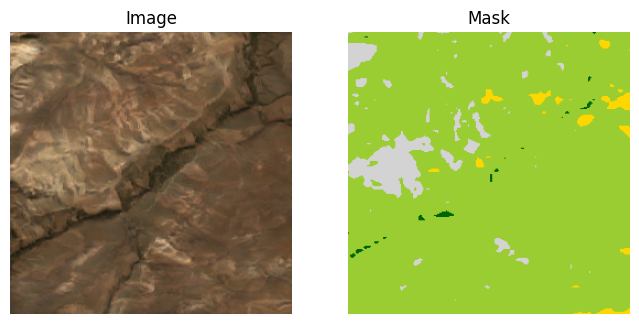

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.title("Mask")
plt.axis("off")

plt.show()

In [ ]:
#The caption for the image
print("Filename:", sample_filename)
print("\nCaption:\n", sample_row["hybrid_gemma3-4b"])

Filename: 0073.png

Caption:
 The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sparse barren land (6%). A prominent drainage channel or gully cuts through the terrain, suggesting a significant fluvial feature within the predominantly grassy area.


**2-Class Mapping and Inspection**

In this step, the mapping between segmentation mask colors and land cover classes is defined, and the mask structure of a sample image is inspected.

The dataset provides segmentation masks in RGB format, where each pixel color corresponds to a specific land cover class. According to the project guideline, each class is associated with a predefined RGB value. Therefore,the dictionary is defined first which maps each class name to its RGB colour.

In [ ]:
# Class to RGB mapping from the project guideline
class_colors = {
    "Tree":      (0, 100, 0),
    "Shrub":     (255, 182, 193),
    "Grass":     (154, 205, 50),
    "Crop":      (255, 215, 0),
    "Built-up":  (139, 69, 19),
    "Barren":    (211, 211, 211),
    "Water":     (0, 0, 255)}

print(class_colors)

{'Tree': (0, 100, 0), 'Shrub': (255, 182, 193), 'Grass': (154, 205, 50), 'Crop': (255, 215, 0), 'Built-up': (139, 69, 19), 'Barren': (211, 211, 211), 'Water': (0, 0, 255)}


The mask image is converted into a NumPy array to enable pixel wise analysis. This allows to examine the structure of the mask and extract unique RGB values from the image.

In [ ]:
# Convert mask to numpy array
mask_np = np.array(mask)

print("Mask shape:", mask_np.shape)
print("First pixel example:", mask_np[0, 0])

Mask shape: (256, 256, 3)
First pixel example: [211 211 211]


Land cover classes from the spesific image can be determşne by identifying the unique colours in the corresponding mask. This step is essential for verifying that the mask encoding is consistent with the provided class color mapping.

In [ ]:
# Find unique RGB colors in the mask
unique_colors = np.unique(mask_np.reshape(-1, 3), axis=0)

print("Number of unique colors in this mask:", len(unique_colors))
print("Unique colors in this mask:")
print(unique_colors)

Number of unique colors in this mask: 4
Unique colors in this mask:
[[  0 100   0]
 [154 205  50]
 [211 211 211]
 [255 215   0]]


Finally,  detected RGB values mapped to its corresponding class name. This ensures that the mask can be correctly interpreted and prepares the foundation for generating ground truth labels in the next step.

In [ ]:
# Reverse mapping: RGB -> class name
color_to_class = {v: k for k, v in class_colors.items()}

# Print color-class matches found in this mask
for color in unique_colors:
    color_tuple = tuple(color)
    class_name = color_to_class.get(color_tuple, "Unknown")
    print(f"Color {color_tuple} -> {class_name}")

Color (np.uint8(0), np.uint8(100), np.uint8(0)) -> Tree
Color (np.uint8(154), np.uint8(205), np.uint8(50)) -> Grass
Color (np.uint8(211), np.uint8(211), np.uint8(211)) -> Barren
Color (np.uint8(255), np.uint8(215), np.uint8(0)) -> Crop


**3-Mask to Label**

In this step, the function which transforms a segmentation mask into a class label. The mask is represented as an RGB image, where each color corresponds to a predefined land cover class. To generate ground truth, the function first counts the number of pixels belonging to each class in the mask. Then, it computes the proportion of each class relative to the total number of pixels.

For the proof of concept, single label setting is used. In this setting the class with the highest pixel count is selected as the ground truth label. This keeps the initial pipeline simple and suitable for demonstrating feasibility. In addition to the dominant label, the function also returns class counts and ratios, which are useful for interpretation and verification.

In [ ]:
def mask_to_label(mask_image, class_colors):
    """
    Convert an RGB mask image into:
    1. pixel counts for each class
    2. class ratios
    3. dominant class label

    Parameters
    ----------
    mask_image : PIL.Image
        RGB mask image
    class_colors : dict
        Dictionary mapping class names to RGB tuples

    Returns
    -------
    counts_dict : dict
        Pixel count for each class
    ratios_dict : dict
        Pixel ratio for each class
    dominant_class : str
        Class with the highest pixel count
    """

    # Convert mask image to NumPy array
    mask_np = np.array(mask_image)

    # Total number of pixels in the mask
    total_pixels = mask_np.shape[0] * mask_np.shape[1]

    # Dictionaries to store counts and ratios
    counts_dict = {}
    ratios_dict = {}

    # Count pixels for each class color
    for class_name, rgb_color in class_colors.items():
        # Create a boolean mask where all RGB channels match the class color
        matches = np.all(mask_np == rgb_color, axis=-1)

        # Count matching pixels
        pixel_count = np.sum(matches)

        # Store count
        counts_dict[class_name] = int(pixel_count)

        # Store ratio
        ratios_dict[class_name] = pixel_count / total_pixels

    # Find the class with the maximum pixel count
    dominant_class = max(counts_dict, key=counts_dict.get)

    return counts_dict, ratios_dict, dominant_class

After defining the function, the sample mask is tested. This helps to verify that the function is working correctly before applying it to the full dataset. The output should show the pixel counts, class ratios, and the dominant class for the selected sample.

In [ ]:
counts_dict, ratios_dict, dominant_class = mask_to_label(mask, class_colors)

print("Pixel counts by class:")
for k, v in counts_dict.items():
    print(f"{k}: {v}")

print("\nClass ratios:")
for k, v in ratios_dict.items():
    print(f"{k}: {v:.4f}")

print("\nDominant class (ground truth label):", dominant_class)

Pixel counts by class:
Tree: 223
Shrub: 0
Grass: 60100
Crop: 1078
Built-up: 0
Barren: 4135
Water: 0

Class ratios:
Tree: 0.0034
Shrub: 0.0000
Grass: 0.9171
Crop: 0.0164
Built-up: 0.0000
Barren: 0.0631
Water: 0.0000

Dominant class (ground truth label): Grass


**4-Building Dataframe with LAbels**

In this step, the new dataframe which stores the essential information for the PoC. For each sample, the code checks whether the corresponding image and mask files exist, loads the mask, generates the dominant class label using the previously defined function, and then stores the caption and label together.

This confirms that the pipeline is compatible with the model and suitable for PoC inference, with training and full evaluation to be conducted in later phases.

Since the dataset is large, a smaller subset during the PoC is used.

In [ ]:
# small subset of the CSV for proof of concept
poc_size = 200
df_poc = df.iloc[:poc_size].copy()

print("PoC subset size:", len(df_poc))
df_poc.head()

PoC subset size: 200


,filename,split,Tree,Shrub,Grass,Crop,Built-up,Barren,Water,hybrid_gemma3-4b,hybrid_qwen3-vl-8b,text_qwen3-4b,vision_gemma3-4b,vision_qwen3-vl-8b
0,0073.png,synth,0,0,92,2,0,6,0,The image depicts a landscape dominated by ext...,The scene is dominated by grassland covering 9...,"The scene is predominantly covered by grass, i...","This image depicts a rugged, arid landscape ch...","This remote sensing image shows a rugged, arid..."
1,0077.png,synth,5,0,87,3,1,4,0,The image depicts a largely arid landscape dom...,"The scene is dominated by grasslands (87%), in...",The scene is predominantly covered by grass (8...,"The image depicts a rugged, arid landscape wit...","This remote sensing image depicts a rugged, ar..."
2,0136.png,synth,4,0,93,0,2,1,0,The image depicts a landscape dominated by ext...,The scene is dominated by grasslands covering ...,"The scene is predominantly grassland, with ove...",The image depicts a semi-arid landscape domina...,"This satellite image shows a rugged, arid moun..."
3,0172.png,synth,72,0,22,4,2,0,0,The image depicts a valley dominated by dense ...,The scene depicts a rural landscape dominated ...,"The scene is predominantly forested, with tree...",The image depicts a small town nestled within ...,This satellite image shows a small rural settl...
4,0198.png,synth,32,0,14,0,0,1,53,The image depicts a coastal area dominated by ...,The scene shows a coastal region dominated by ...,"The scene is predominantly water, covering 53%...",This image shows a coastal landscape with a na...,This satellite image shows a coastal peninsula...


In [ ]:
# The caption columns that is going to be used
caption_column = "hybrid_gemma3-4b"

# List to store processed dataset rows
data_rows = []

for _, row in df_poc.iterrows():
    filename = row["filename"]

    # Build full file paths
    image_path = os.path.join(images_path, filename)
    mask_path = os.path.join(masks_path, filename)

    # Skip samples if image or mask file is missing
    if not os.path.exists(image_path) or not os.path.exists(mask_path):
        continue

    # Load the mask image
    mask_image = Image.open(mask_path).convert("RGB")

    # Generate counts, ratios, and dominant label from the mask
    counts_dict, ratios_dict, dominant_class = mask_to_label(mask_image, class_colors)

    # Store sample information
    data_rows.append({
        "filename": filename,
        "image_path": image_path,
        "mask_path": mask_path,
        "caption": row[caption_column],
        "label_name": dominant_class
    })

Samples were processed and stored in a Python list. Now, this list is converted into a pandas dataframe.

In [ ]:
# convert the collected rows into a dataframe
data_df = pd.DataFrame(data_rows)

# Check how many valid samples were created
print("Number of valid samples in PoC dataframe:", len(data_df))

# Show first 5 rows
data_df.head()

Number of valid samples in PoC dataframe: 200


,filename,image_path,mask_path,caption,label_name
0,0073.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a landscape dominated by ext...,Grass
1,0077.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a largely arid landscape dom...,Grass
2,0136.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a landscape dominated by ext...,Grass
3,0172.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a valley dominated by dense ...,Tree
4,0198.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a coastal area dominated by ...,Water


The ground truth labels are currently stored as text values such as "Grass" or "Barren". However, the model requires numeric targets. Therefore, the fixed class order defined and each class name converted into a corresponding integer label.

In [ ]:
# Define the class order used in the project
class_names = ["Tree", "Shrub", "Grass", "Crop", "Built-up", "Barren", "Water"]

# Create mapping dictionaries
class_to_id = {class_name: idx for idx, class_name in enumerate(class_names)}
id_to_class = {idx: class_name for class_name, idx in class_to_id.items()}

# Encode label names into integers
data_df["label_id"] = data_df["label_name"].map(class_to_id)

# Inspect encoded labels
data_df[["filename", "label_name", "label_id"]].head()

,filename,label_name,label_id
0,0073.png,Grass,2
1,0077.png,Grass,2
2,0136.png,Grass,2
3,0172.png,Tree,0
4,0198.png,Water,6


In [ ]:
# Check the distribution of dominant classes
print(data_df["label_name"].value_counts())

label_name
Grass       101
Tree         66
Crop         26
Water         4
Barren        2
Built-up      1
Name: count, dtype: int64


In [ ]:
# Inspect one processed sample
sample_processed = data_df.iloc[0]

print("Filename:", sample_processed["filename"])
print("Image path:", sample_processed["image_path"])
print("Mask path:", sample_processed["mask_path"])
print("Caption:", sample_processed["caption"])
print("Label name:", sample_processed["label_name"])
print("Label id:", sample_processed["label_id"])

Filename: 0073.png
Image path: /content/drive/MyDrive/DI725_Transformer/TermProject/images/0073.png
Mask path: /content/drive/MyDrive/DI725_Transformer/TermProject/masks/0073.png
Caption: The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sparse barren land (6%). A prominent drainage channel or gully cuts through the terrain, suggesting a significant fluvial feature within the predominantly grassy area.
Label name: Grass
Label id: 2


**5-Train / Validation / Test Split**

In this step, the processed PoC dataframe is divided into training, validation, and test sets.

Normally, stratified splitting should be used to preserve class distributions in the train validation and test set. But it is seen from previous outputs that there is only 1 "Built-up" image in this subset, which means it is not suitable for stratified sampling.

Since the goal of the proof of concept is to demonstrate feasibility rather than perfect class balancing, a standard random split is used at this stage.

In [ ]:
print("Processed PoC dataset size:", len(data_df))

Processed PoC dataset size: 200


In [ ]:
# Non-stratified split for PoC
train_df, temp_df = train_test_split(
    data_df,
    test_size=0.4,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 120
Validation size: 40
Test size: 40


In [ ]:
print("Train class distribution:\n", train_df["label_name"].value_counts(), "\n")
print("Validation class distribution:\n", val_df["label_name"].value_counts(), "\n")
print("Test class distribution:\n", test_df["label_name"].value_counts())

Train class distribution:
 label_name
Grass     65
Tree      32
Crop      19
Water      3
Barren     1
Name: count, dtype: int64 

Validation class distribution:
 label_name
Tree        18
Grass       18
Crop         2
Water        1
Built-up     1
Name: count, dtype: int64 

Test class distribution:
 label_name
Grass     18
Tree      16
Crop       5
Barren     1
Name: count, dtype: int64


**6-FLAVA Inputs Preparing**

FLAVA requires inputs to be formatted in a specific way. The processor handles this preparation step. It converts raw images and text into tensors that are compatible with the FLAVA model. The same processor used for both image only and image+text settings so that the input pipeline remains consistent.

In [ ]:
from transformers import FlavaProcessor

# Load the FLAVA processor
processor = FlavaProcessor.from_pretrained("facebook/flava-full")

print("FLAVA processor loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/881 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/358 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

FLAVA processor loaded successfully.


In this step, a custom PyTorch dataset class is designed. This class reads one sample at a time from the dataframe, loads the image, takes the caption, and prepares the input using the FLAVA processor.

To keep the project aligned with design, the dataset class supports both image only mode and image + text mode.

This allows to use the same dataset structure for both experiments later.

In [ ]:
class FlavaClassificationDataset(Dataset):
    def __init__(self, dataframe, processor, use_text=True):
        """
        Parameters
        ----------
        dataframe : pd.DataFrame
            Dataframe containing image path, caption, and label
        processor : FlavaProcessor
            Hugging Face processor for FLAVA
        use_text : bool
            If True, use image + text
            If False, use image only
        """
        self.dataframe = dataframe
        self.processor = processor
        self.use_text = use_text  #use_Text=True means image + caption mode, use_text=False means image mode

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        # load image and convert to RGB to ensure consistent format
        image = Image.open(row["image_path"]).convert("RGB")

        # Get caption only if text is enabled
        text = row["caption"] if self.use_text else ""

        # Process image and text together
        encoding = self.processor(
            images=image,
            text=text,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=64
        )

        # Remove the extra batch dimension added by the processor
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}

        # Add label
        encoding["labels"] = torch.tensor(row["label_id"], dtype=torch.long)

        return encoding

In [ ]:
# Image-only datasets
train_dataset_img = FlavaClassificationDataset(train_df, processor, use_text=False)
val_dataset_img = FlavaClassificationDataset(val_df, processor, use_text=False)
test_dataset_img = FlavaClassificationDataset(test_df, processor, use_text=False)

# image + text datasets
train_dataset_multimodal = FlavaClassificationDataset(train_df, processor, use_text=True)
val_dataset_multimodal = FlavaClassificationDataset(val_df, processor, use_text=True)
test_dataset_multimodal = FlavaClassificationDataset(test_df, processor, use_text=True)

print("Datasets created successfully.")

Datasets created successfully.


Before creating dataloaders or training the model, one processed sample is inspected. This helps to verify that the dataset is returning the expected FLAVA inputs and the correct label.

In [ ]:
# Inspect one image-only sample
sample_img = train_dataset_img[0]

print("Image-only sample keys:", sample_img.keys())
for k, v in sample_img.items():
    print(k, v.shape if hasattr(v, "shape") else v)

Image-only sample keys: dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])
pixel_values torch.Size([3, 224, 224])
input_ids torch.Size([64])
token_type_ids torch.Size([64])
attention_mask torch.Size([64])
labels torch.Size([])


The multimodal version of the dataset checked and to confirm that both image and caption are being prepared correctly.

In [ ]:
# inspect one image + text sample
sample_multi = train_dataset_multimodal[0]

print("Image + text sample keys:", sample_multi.keys())
for k, v in sample_multi.items():
    print(k, v.shape if hasattr(v, "shape") else v)

Image + text sample keys: dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])
pixel_values torch.Size([3, 224, 224])
input_ids torch.Size([64])
token_type_ids torch.Size([64])
attention_mask torch.Size([64])
labels torch.Size([])


This step verifies that both image only and image+text inputs can be successfully processed using the FLAVA processor. The dataset returns correctly formatted tensors, including image features and tokenized text inputs, along with corresponding ground truth labels. This confirms that the data pipeline is compatible with the FLAVA model and suitable for subsequent training and evaluation.

The outputs for both image only and image+text samples appear structurally identical. This is expected behavior due to the design of the FLAVA model. This model is a unified multimodal transformer which processes both image and text inputs inthe same architecture. Therefore even in the image only setting, the model still needs a text related inputs like "input_ids", "attention_mask" and "token_type_ids"

In the image only case, these text inputs are typically empty or default placeholders. On the other hand,  in the image+text case, it contains meaningful tokenized captions.

**7-Dataloaders for Image Only Setting**

In this step, dataloaders are created for the image only version of the experiment.

A dataloader groups dataset samples into batches, which makes model training and evaluation more efficient.

The training dataloader uses shuffling so that samples are presented in random order during training, while validation and test dataloaders keep the original order.

In [ ]:
# batch size for PoC
batch_size = 8

# Image only dataloaders
train_loader_img = DataLoader(train_dataset_img, batch_size=batch_size, shuffle=True)
val_loader_img = DataLoader(val_dataset_img, batch_size=batch_size, shuffle=False)
test_loader_img = DataLoader(test_dataset_img, batch_size=batch_size, shuffle=False)

print("Image-only dataloaders created successfully.")

Image-only dataloaders created successfully.


**8-Dataloaders for Image+TExt**

This step creates dataloaders for the multimodal version of the experiment, where both images and captions are used as input. The same batching logic is applied so that the two settings remain comparabl

In [ ]:
# Image + text dataloaders
train_loader_multi = DataLoader(train_dataset_multimodal, batch_size=batch_size, shuffle=True)
val_loader_multi = DataLoader(val_dataset_multimodal, batch_size=batch_size, shuffle=False)
test_loader_multi = DataLoader(test_dataset_multimodal, batch_size=batch_size, shuffle=False)

print("Image + text dataloaders created successfully.")

Image + text dataloaders created successfully.


In [ ]:
# Inspect one batch from image-only dataloader
batch_img = next(iter(train_loader_img))

print("Image-only batch keys:", batch_img.keys())
for k, v in batch_img.items():
    print(k, v.shape)

Image-only batch keys: dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])
pixel_values torch.Size([8, 3, 224, 224])
input_ids torch.Size([8, 64])
token_type_ids torch.Size([8, 64])
attention_mask torch.Size([8, 64])
labels torch.Size([8])


In [ ]:
# Inspect one batch from image + text dataloader
batch_multi = next(iter(train_loader_multi))

print("Image + text batch keys:", batch_multi.keys())
for k, v in batch_multi.items():
    print(k, v.shape)

Image + text batch keys: dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])
pixel_values torch.Size([8, 3, 224, 224])
input_ids torch.Size([8, 64])
token_type_ids torch.Size([8, 64])
attention_mask torch.Size([8, 64])
labels torch.Size([8])


This step verifies that both image only and image+text datasets can be successfully batched using PyTorch DataLoaders.

Like mentioned before, the image only setting uses empty text inputs. On the other hand, the image+text setting incorporates meaningful captionsç

This confirms that the data pipeline is fully compatible with the FLAVA model and ready for training.

**9-FLAVA Model**

In this step, the custom classification model built on top of FLAVA is defined.

The FLAVA backbone is used as a feature extractor, and a linear classification head is added to map the learned representation to the project’s 7 land cover classes.

The same model structure will be used for both image only and image+text. This keeps the architecture fixed and ensures that the comparison focuses on the effect of adding captions rather than changing the model design.

For the PoC, the multimodal representation is used when text is available and the image representation when text is not used.

In [ ]:
class FlavaForClassification(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # Load pretrained FLAVA backbone
        self.flava = FlavaModel.from_pretrained("facebook/flava-full")

        # FLAVA hidden size is 768 for the base model
        hidden_size = self.flava.config.hidden_size

        # Simple classification head
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, pixel_values, input_ids, attention_mask, token_type_ids, use_text=True):
        # Get FLAVA outputs
        outputs = self.flava(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True
        )

        # If text is used, take multimodal pooled output
        if use_text:
            pooled_output = outputs.multimodal_output.pooler_output
        else:
            # If text is not used, take image pooled output
            pooled_output = outputs.image_output.pooler_output

        # Classification logits
        logits = self.classifier(pooled_output)

        return logits

After defining the model class, it is  instantiated and moved to the selected device. This prepares the model for forward passes and later training.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Number of project classes
num_classes = len(class_names)

# Create model
model = FlavaForClassification(num_classes=num_classes).to(device)

print("Model created successfully.")
print("Using device:", device)

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_4.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_3.group.block_2.res_path.path.conv_1.weight | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_2.res_path.path.conv_4.weight | UNEXPECTED |  | 
mmm_text_head.transform.LayerNorm.bias                                  | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_2.res_path.path.conv_4.bias   | UNEXPECTED |  | 
itm_head.pooler.dense.weight                                            | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block_2.res_path.path.conv_3.weight | UNEXPECTED |  | 
image_codebook.blocks.group_4.group.block

Model created successfully.
Using device: cuda


Since this is a single label classification problem in the PoC stage, the  CrossEntropyLoss is used. This is the standard loss for multiclass classification when each sample belongs to exactly one class.

The AdamW optimizer is used during training for model weight updates.

In [ ]:
# Loss function for single-label classification
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

print("Loss and optimizer are ready.")

Loss and optimizer are ready.


Before training, the model tested with one batch from the image only dataloader. It confirms that the forward pass works correctly and that the output has the expected shape.

In [ ]:
# Get one image-only batch
batch_img = next(iter(train_loader_img))
batch_img = {k: v.to(device) for k, v in batch_img.items()}

# Forward pass in image-only mode
with torch.no_grad():
    logits_img = model(
        pixel_values=batch_img["pixel_values"],
        input_ids=batch_img["input_ids"],
        attention_mask=batch_img["attention_mask"],
        token_type_ids=batch_img["token_type_ids"],
        use_text=False
    )

print("Image-only logits shape:", logits_img.shape)

Image-only logits shape: torch.Size([8, 7])


The multimodal also tested with one batch from the image+text dataloader.

In [ ]:
# Get one image + text batch
batch_multi = next(iter(train_loader_multi))
batch_multi = {k: v.to(device) for k, v in batch_multi.items()}

# Forward pass in image + text mode
with torch.no_grad():
    logits_multi = model(
        pixel_values=batch_multi["pixel_values"],
        input_ids=batch_multi["input_ids"],
        attention_mask=batch_multi["attention_mask"],
        token_type_ids=batch_multi["token_type_ids"],
        use_text=True
    )

print("Image + text logits shape:", logits_multi.shape)

Image + text logits shape: torch.Size([8, 7])


In [ ]:
# Convert logits to predicted class ids
preds_img = torch.argmax(logits_img, dim=1)
preds_multi = torch.argmax(logits_multi, dim=1)

print("Image-only predicted class ids:", preds_img.cpu().numpy())
print("Image + text predicted class ids:", preds_multi.cpu().numpy())
print("True labels:", batch_img["labels"].cpu().numpy())

Image-only predicted class ids: [6 6 6 6 6 6 6 6]
Image + text predicted class ids: [6 6 6 6 6 6 6 6]
True labels: [2 2 2 2 2 2 0 2]


In this final step, the model outputs were converted into predicted class labels and compared with the corresponding ground truth labels derived from segmentation masks. The results show that both image only and image+text configurations currently produce similar predictions, which do not yet align with the true labels.

This behavior is expected at the PoC stage, as the classification head has not been trained and the model weights have not been fine tuned for the specific task. The predictions therefore reflect the initial state of the model rather than meaningful learning.

Despite this, the experiment successfully demonstrates that the complete pipeline from data loading and mask based ground truth generation to FLAVA based multimodal input processing and prediction. The model produces valid logits and class predictions that can be directly compared with ground truth labels.

It confirms the feasibility of the proposed approach. In subsequent phases, training and optimization will be applied to evaluate whether incorporating textual information improves classification performance compared to the image only setting.